<a href="https://colab.research.google.com/github/evakonstantinova/EfficientNet-B0/blob/main/EfficientNet_B0_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# DATASET DOWNLOAD AND STRATIFIED SPLIT

from pathlib import Path
from collections import Counter

import kagglehub
from sklearn.model_selection import train_test_split

path = kagglehub.dataset_download(
    "masoudnickparvar/brain-tumor-mri-dataset"
)

classes = ["glioma", "meningioma", "notumor", "pituitary"]

all_files = []
all_labels = []

for class_name in classes:
    for folder in ["Training", "Testing"]:
        class_path = Path(path) / folder / class_name

        for file_path in class_path.iterdir():
            if file_path.is_file():
                all_files.append(str(file_path))
                all_labels.append(class_name)

train_files, temp_files, train_labels, temp_labels = train_test_split(
    all_files,
    all_labels,
    test_size=0.30,
    random_state=42,
    stratify=all_labels
)

val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Dataset path:", path)
print("Total images:", len(all_files))
print("Overall distribution:", Counter(all_labels))
print("Training:", len(train_files), Counter(train_labels))
print("Validation:", len(val_files), Counter(val_labels))
print("Testing:", len(test_files), Counter(test_labels))

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset path: /kaggle/input/brain-tumor-mri-dataset
Total images: 7200
Overall distribution: Counter({'glioma': 1800, 'meningioma': 1800, 'notumor': 1800, 'pituitary': 1800})
Training: 5040 Counter({'notumor': 1260, 'pituitary': 1260, 'glioma': 1260, 'meningioma': 1260})
Validation: 1080 Counter({'notumor': 270, 'glioma': 270, 'meningioma': 270, 'pituitary': 270})
Testing: 1080 Counter({'meningioma': 270, 'notumor': 270, 'glioma': 270, 'pituitary': 270})


In [ ]:
# DATA PREPROCESSING AND DATALOADERS

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class_to_idx = {
    "glioma": 0,
    "meningioma": 1,
    "notumor": 2,
    "pituitary": 3
}

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class BrainTumorDataset(Dataset):
    def __init__(self, files, labels, transform=None):
        self.files = files
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        image = Image.open(self.files[idx]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = class_to_idx[self.labels[idx]]
        return image, label

train_dataset = BrainTumorDataset(
    train_files,
    train_labels,
    transform=train_transform
)

val_dataset = BrainTumorDataset(
    val_files,
    val_labels,
    transform=val_test_transform
)

test_dataset = BrainTumorDataset(
    test_files,
    test_labels,
    transform=val_test_transform
)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 5040
Validation dataset: 1080
Test dataset: 1080


In [ ]:
# TRANSFER LEARNING — PRETRAINED EFFICIENTNET-B0 AND STAGE 1 CLASSIFIER SETUP

import torch.nn as nn
import torch.optim as optim
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.metrics import f1_score

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

for param in model.features.parameters():
    param.requires_grad = False

num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 4)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

NUM_EPOCHS = 10
best_val_loss = float("inf")

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_f1_scores = []
val_f1_scores = []

print("Device:", device)
print("Features entering classifier:", num_features)
print("Total parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 164MB/s]


Device: cuda
Features entering classifier: 1280
Total parameters: 4,012,672
Trainable parameters: 5,124


In [ ]:
%%time

# TRANSFER LEARNING — STAGE 1 INITIAL CLASSIFIER TRAINING

for epoch in range(NUM_EPOCHS):
    model.train()
    model.features.eval()

    running_loss = 0.0
    train_predictions = []
    train_true_labels = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = torch.argmax(outputs, dim=1)

        train_predictions.extend(predictions.detach().cpu().numpy())
        train_true_labels.extend(labels.detach().cpu().numpy())

    train_loss = running_loss / len(train_dataset)
    train_accuracy = sum(
        p == t for p, t in zip(train_predictions, train_true_labels)
    ) / len(train_true_labels)
    train_f1 = f1_score(
        train_true_labels,
        train_predictions,
        average="macro"
    )

    model.eval()

    running_val_loss = 0.0
    val_predictions = []
    val_true_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            predictions = torch.argmax(outputs, dim=1)

            val_predictions.extend(predictions.cpu().numpy())
            val_true_labels.extend(labels.cpu().numpy())

    val_loss = running_val_loss / len(val_dataset)
    val_accuracy = sum(
        p == t for p, t in zip(val_predictions, val_true_labels)
    ) / len(val_true_labels)
    val_f1 = f1_score(
        val_true_labels,
        val_predictions,
        average="macro"
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    train_f1_scores.append(train_f1)
    val_f1_scores.append(val_f1)

    saved = ""

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            model.state_dict(),
            "/content/best_efficientnet_b0.pth"
        )
        saved = " <-- BEST MODEL SAVED"

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val F1: {val_f1:.4f}"
        f"{saved}"
    )

Epoch 01/10 | Train Loss: 0.5922 | Train Acc: 0.7942 | Train F1: 0.7922 | Val Loss: 0.4343 | Val Acc: 0.8389 | Val F1: 0.8321 <-- BEST MODEL SAVED
Epoch 02/10 | Train Loss: 0.3731 | Train Acc: 0.8732 | Train F1: 0.8728 | Val Loss: 0.3548 | Val Acc: 0.8731 | Val F1: 0.8721 <-- BEST MODEL SAVED
Epoch 03/10 | Train Loss: 0.3283 | Train Acc: 0.8887 | Train F1: 0.8884 | Val Loss: 0.3248 | Val Acc: 0.8861 | Val F1: 0.8842 <-- BEST MODEL SAVED
Epoch 04/10 | Train Loss: 0.2966 | Train Acc: 0.9004 | Train F1: 0.9002 | Val Loss: 0.2988 | Val Acc: 0.8954 | Val F1: 0.8946 <-- BEST MODEL SAVED
Epoch 05/10 | Train Loss: 0.2826 | Train Acc: 0.9004 | Train F1: 0.9003 | Val Loss: 0.2853 | Val Acc: 0.8963 | Val F1: 0.8953 <-- BEST MODEL SAVED
Epoch 06/10 | Train Loss: 0.2711 | Train Acc: 0.9044 | Train F1: 0.9043 | Val Loss: 0.2764 | Val Acc: 0.8972 | Val F1: 0.8968 <-- BEST MODEL SAVED
Epoch 07/10 | Train Loss: 0.2663 | Train Acc: 0.9048 | Train F1: 0.9047 | Val Loss: 0.2730 | Val Acc: 0.8926 | Val F1:

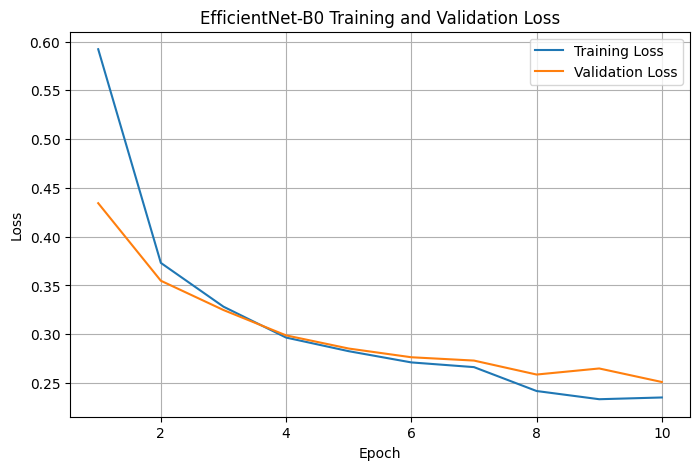

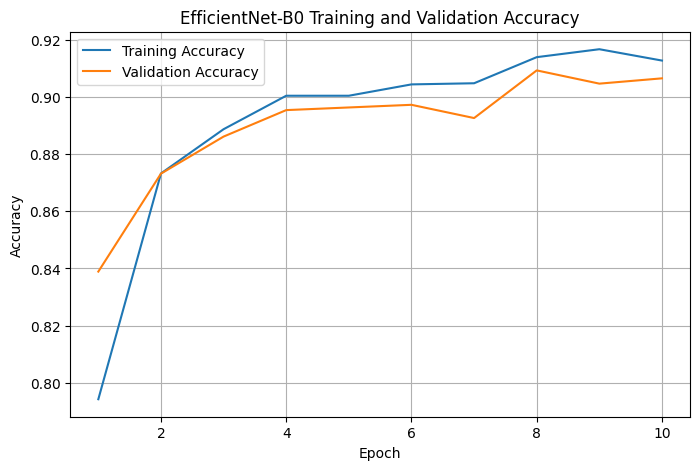

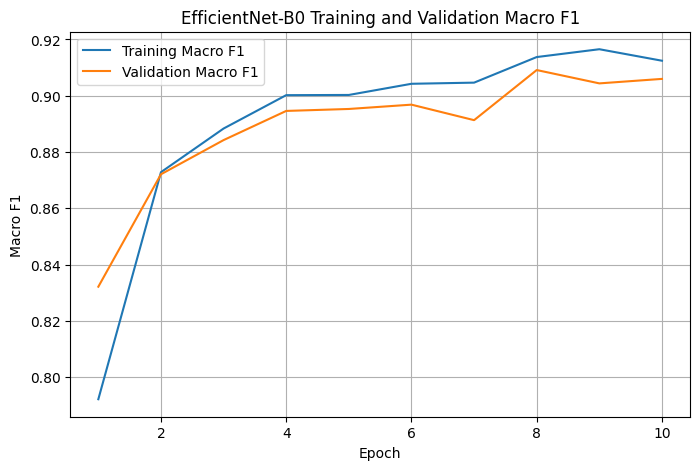

In [ ]:
# STAGE 1 TRAINING CURVES

import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Training Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, label="Training Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet-B0 Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_f1_scores, label="Training Macro F1")
plt.plot(epochs, val_f1_scores, label="Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("EfficientNet-B0 Training and Validation Macro F1")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# FINE-TUNING — LOAD BEST STAGE 1 MODEL AND UNFREEZE FINAL TWO FEATURE BLOCKS

model.load_state_dict(
    torch.load(
        "/content/best_efficientnet_b0.pth",
        weights_only=True
    )
)

for param in model.features.parameters():
    param.requires_grad = False

for param in model.features[-2:].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001,
    weight_decay=0.0001
)

FINE_TUNE_EPOCHS = 10
patience = 3
min_delta = 0.001

best_ft_val_loss = float("inf")
early_stop_best_loss = None
epochs_without_improvement = 0

ft_train_losses = []
ft_val_losses = []
ft_train_accuracies = []
ft_val_accuracies = []
ft_train_f1_scores = []
ft_val_f1_scores = []

print("Total parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")

Total parameters: 4,012,672
Trainable parameters: 1,134,516


In [ ]:
%%time

# FINE-TUNING — TRAIN UP TO 10 EPOCHS WITH EARLY STOPPING FROM EPOCH 6

for epoch in range(FINE_TUNE_EPOCHS):
    model.train()

    running_loss = 0.0
    train_predictions = []
    train_true_labels = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = torch.argmax(outputs, dim=1)

        train_predictions.extend(predictions.detach().cpu().numpy())
        train_true_labels.extend(labels.detach().cpu().numpy())

    train_loss = running_loss / len(train_dataset)
    train_accuracy = sum(
        p == t for p, t in zip(train_predictions, train_true_labels)
    ) / len(train_true_labels)
    train_f1 = f1_score(
        train_true_labels,
        train_predictions,
        average="macro"
    )

    model.eval()

    running_val_loss = 0.0
    val_predictions = []
    val_true_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            predictions = torch.argmax(outputs, dim=1)

            val_predictions.extend(predictions.cpu().numpy())
            val_true_labels.extend(labels.cpu().numpy())

    val_loss = running_val_loss / len(val_dataset)
    val_accuracy = sum(
        p == t for p, t in zip(val_predictions, val_true_labels)
    ) / len(val_true_labels)
    val_f1 = f1_score(
        val_true_labels,
        val_predictions,
        average="macro"
    )

    ft_train_losses.append(train_loss)
    ft_val_losses.append(val_loss)
    ft_train_accuracies.append(train_accuracy)
    ft_val_accuracies.append(val_accuracy)
    ft_train_f1_scores.append(train_f1)
    ft_val_f1_scores.append(val_f1)

    saved = ""

    if val_loss < best_ft_val_loss:
        best_ft_val_loss = val_loss
        torch.save(
            model.state_dict(),
            "/content/best_efficientnet_b0_finetuned.pth"
        )
        saved = " <-- BEST MODEL SAVED"

    if epoch == 4:
        early_stop_best_loss = best_ft_val_loss

    elif epoch >= 5:
        if val_loss < early_stop_best_loss - min_delta:
            early_stop_best_loss = val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

    print(
        f"Epoch {epoch + 1:02d}/{FINE_TUNE_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val F1: {val_f1:.4f}"
        f"{saved}"
    )

    if epoch >= 5 and epochs_without_improvement >= patience:
        print(f"Early stopping triggered at epoch {epoch + 1}.")
        break

Epoch 01/10 | Train Loss: 0.4694 | Train Acc: 0.8341 | Train F1: 0.8332 | Val Loss: 0.2929 | Val Acc: 0.8935 | Val F1: 0.8924 <-- BEST MODEL SAVED
Epoch 02/10 | Train Loss: 0.2939 | Train Acc: 0.8944 | Train F1: 0.8944 | Val Loss: 0.2176 | Val Acc: 0.9185 | Val F1: 0.9189 <-- BEST MODEL SAVED
Epoch 03/10 | Train Loss: 0.2395 | Train Acc: 0.9115 | Train F1: 0.9114 | Val Loss: 0.1929 | Val Acc: 0.9306 | Val F1: 0.9300 <-- BEST MODEL SAVED
Epoch 04/10 | Train Loss: 0.2042 | Train Acc: 0.9244 | Train F1: 0.9243 | Val Loss: 0.1744 | Val Acc: 0.9398 | Val F1: 0.9398 <-- BEST MODEL SAVED
Epoch 05/10 | Train Loss: 0.1909 | Train Acc: 0.9290 | Train F1: 0.9289 | Val Loss: 0.1575 | Val Acc: 0.9500 | Val F1: 0.9497 <-- BEST MODEL SAVED
Epoch 06/10 | Train Loss: 0.1709 | Train Acc: 0.9401 | Train F1: 0.9400 | Val Loss: 0.1310 | Val Acc: 0.9537 | Val F1: 0.9535 <-- BEST MODEL SAVED
Epoch 07/10 | Train Loss: 0.1586 | Train Acc: 0.9411 | Train F1: 0.9410 | Val Loss: 0.1159 | Val Acc: 0.9630 | Val F1:

   Epoch  Train Loss  Train Accuracy  Train Macro F1  Validation Loss  \
0      1    0.469415        0.834127        0.833182         0.292935   
1      2    0.293922        0.894444        0.894420         0.217614   
2      3    0.239544        0.911508        0.911416         0.192920   
3      4    0.204156        0.924405        0.924301         0.174374   
4      5    0.190897        0.928968        0.928917         0.157479   
5      6    0.170931        0.940079        0.939955         0.130968   
6      7    0.158602        0.941071        0.941033         0.115945   
7      8    0.141784        0.950397        0.950420         0.118036   
8      9    0.129370        0.954762        0.954717         0.089625   
9     10    0.112233        0.962302        0.962319         0.100015   

   Validation Accuracy  Validation Macro F1  
0             0.893519             0.892432  
1             0.918519             0.918878  
2             0.930556             0.930027  
3           

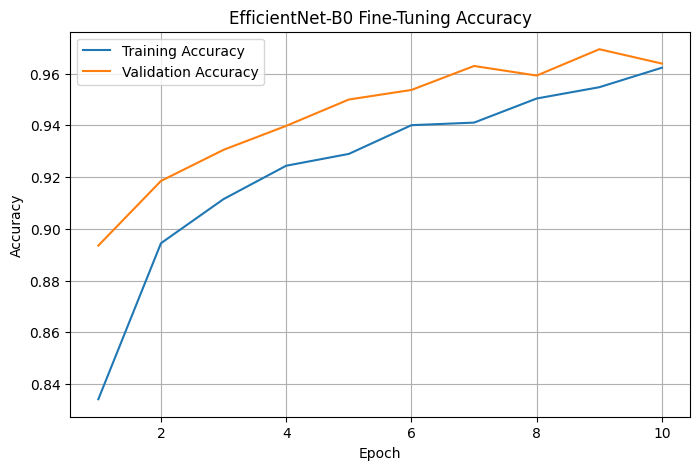

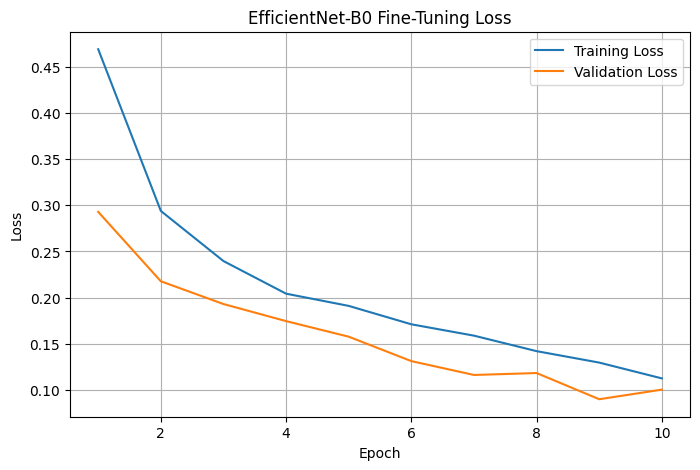

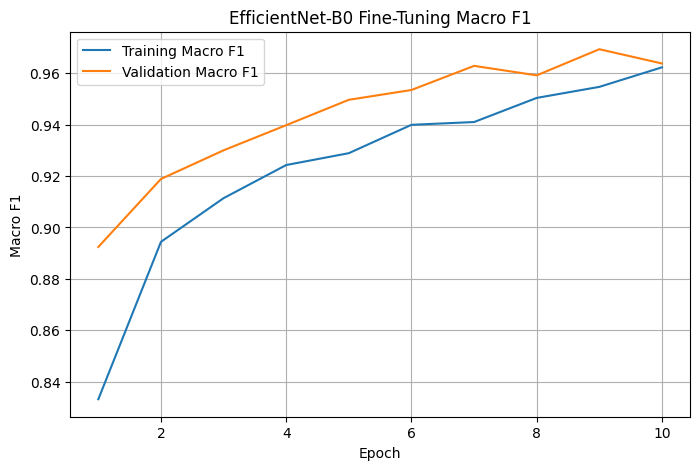

In [ ]:
# FINE-TUNING RESULTS AND CURVES

import numpy as np
import pandas as pd

fine_tuning_results = pd.DataFrame({
    "Epoch": range(1, len(ft_train_losses) + 1),
    "Train Loss": ft_train_losses,
    "Train Accuracy": ft_train_accuracies,
    "Train Macro F1": ft_train_f1_scores,
    "Validation Loss": ft_val_losses,
    "Validation Accuracy": ft_val_accuracies,
    "Validation Macro F1": ft_val_f1_scores
})

fine_tuning_results.to_csv(
    "/content/efficientnet_b0_finetuning_results.csv",
    index=False
)

best_ft_epoch = int(np.argmin(ft_val_losses)) + 1
highest_val_accuracy_epoch = int(np.argmax(ft_val_accuracies)) + 1

print(fine_tuning_results)
print("\nBest checkpoint epoch:", best_ft_epoch)
print("Best validation loss:", f"{min(ft_val_losses):.4f}")
print("Highest validation accuracy:", f"{max(ft_val_accuracies):.4f}")
print("Highest validation accuracy epoch:", highest_val_accuracy_epoch)

epochs = range(1, len(ft_train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, ft_train_accuracies, label="Training Accuracy")
plt.plot(epochs, ft_val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet-B0 Fine-Tuning Accuracy")
plt.legend()
plt.grid()
plt.savefig(
    "/content/efficientnet_b0_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, ft_train_losses, label="Training Loss")
plt.plot(epochs, ft_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Fine-Tuning Loss")
plt.legend()
plt.grid()
plt.savefig(
    "/content/efficientnet_b0_loss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, ft_train_f1_scores, label="Training Macro F1")
plt.plot(epochs, ft_val_f1_scores, label="Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("EfficientNet-B0 Fine-Tuning Macro F1")
plt.legend()
plt.grid()
plt.savefig(
    "/content/efficientnet_b0_f1.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# SAVE REPRODUCIBILITY INFORMATION

import json

train_split = pd.DataFrame({
    "file": train_files,
    "label": train_labels
})

val_split = pd.DataFrame({
    "file": val_files,
    "label": val_labels
})

test_split = pd.DataFrame({
    "file": test_files,
    "label": test_labels
})

train_split.to_csv("/content/train_split.csv", index=False)
val_split.to_csv("/content/validation_split.csv", index=False)
test_split.to_csv("/content/test_split.csv", index=False)

best_index = int(np.argmin(ft_val_losses))
highest_accuracy_index = int(np.argmax(ft_val_accuracies))

experiment_info = {
    "model": "EfficientNet-B0",
    "dataset_size": len(all_files),
    "classes": classes,
    "train_size": len(train_dataset),
    "validation_size": len(val_dataset),
    "test_size": len(test_dataset),
    "input_size": "224x224x3",
    "batch_size": BATCH_SIZE,
    "random_seed": 42,
    "stage_1_epochs": NUM_EPOCHS,
    "stage_1_trainable_parameters": 5124,
    "fine_tuning_epochs_completed": len(ft_train_losses),
    "optimizer": "AdamW",
    "fine_tuning_learning_rate": 0.0001,
    "weight_decay": 0.0001,
    "total_parameters": total_params,
    "fine_tuning_trainable_parameters": trainable_params,
    "checkpoint_selection": "minimum validation loss",
    "best_checkpoint_epoch": best_index + 1,
    "best_validation_loss": ft_val_losses[best_index],
    "best_checkpoint_validation_accuracy": ft_val_accuracies[best_index],
    "best_checkpoint_validation_macro_f1": ft_val_f1_scores[best_index],
    "highest_validation_accuracy": ft_val_accuracies[highest_accuracy_index],
    "highest_validation_accuracy_epoch": highest_accuracy_index + 1
}

with open(
    "/content/efficientnet_b0_experiment_info.json",
    "w"
) as f:
    json.dump(experiment_info, f, indent=4)

print("Split CSV files and experiment information saved.")

Split CSV files and experiment information saved.


In [ ]:
# FINAL TESTING — LOAD BEST FINE-TUNED CHECKPOINT AND EVALUATE THE TEST SET

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    roc_auc_score
)

model.load_state_dict(
    torch.load(
        "/content/best_efficientnet_b0_finetuned.pth",
        weights_only=True
    )
)

model.eval()

test_predictions = []
test_true_labels = []
test_probabilities = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)

        test_predictions.extend(predictions.cpu().numpy())
        test_true_labels.extend(labels.cpu().numpy())
        test_probabilities.extend(probabilities.cpu().numpy())

test_predictions = np.array(test_predictions)
test_true_labels = np.array(test_true_labels)
test_probabilities = np.array(test_probabilities)

test_accuracy = accuracy_score(
    test_true_labels,
    test_predictions
)

test_f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="macro"
)

test_precision = precision_score(
    test_true_labels,
    test_predictions,
    average="macro"
)

test_recall = recall_score(
    test_true_labels,
    test_predictions,
    average="macro"
)

test_auc = roc_auc_score(
    test_true_labels,
    test_probabilities,
    multi_class="ovr",
    average="macro"
)

print("FINAL TEST RESULTS")
print("-----------------------------")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Macro F1:  {test_f1:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"ROC-AUC:   {test_auc:.4f}")

class_names = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]

print(
    classification_report(
        test_true_labels,
        test_predictions,
        target_names=class_names,
        digits=4
    )
)

FINAL TEST RESULTS
-----------------------------
Accuracy:  0.9537
Macro F1:  0.9536
Precision: 0.9542
Recall:    0.9537
ROC-AUC:   0.9953
              precision    recall  f1-score   support

      Glioma     0.9644    0.9037    0.9331       270
  Meningioma     0.9000    0.9333    0.9164       270
    No Tumor     0.9780    0.9889    0.9834       270
   Pituitary     0.9745    0.9889    0.9816       270

    accuracy                         0.9537      1080
   macro avg     0.9542    0.9537    0.9536      1080
weighted avg     0.9542    0.9537    0.9536      1080

